# 📊 Titanic Mini Data Visualization Dashboard
**Internship Task 4 | Data Science & Data Analysis**

## 1. Overview
This notebook presents a comprehensive mini data visualization dashboard utilizing the Titanic dataset. The goal is to build an analytical story by cleaning historical passenger logs, engineering meaningful features, and visualizing key survival dynamics using Matplotlib and Seaborn.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn theme and styling parameters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
# Load the dataset directly via an open-source URL to ensure portability
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Print initial metadata summary
print("--- Initial Dataset Info ---")
df.info()

# Handle missing values: Impute continuous variables with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Impute categorical variables with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop sparse or unnecessary features to prevent noise
df.drop(columns=["Cabin", "Ticket", "Name"], errors="ignore", inplace=True)

print("\n--- Cleaned Dataset Info ---")
df.info()

--- Initial Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- Cleaned Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----

## 2. Feature Engineering
We synthesize two targeted features from baseline attributes to map out demographic groups and traveling team dynamics more effectively.

In [3]:
# 1. FamilySize: Aggregate Sibling/Spouse and Parent/Child counts (+1 for the passenger themselves)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# 2. AgeGroup: Bin continuous ages into distinct lifecycle categories
bins = [0, 12, 18, 30, 50, 80]
labels = ["Child", "Teen", "YoungAdult", "Adult", "Senior"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

print(df[["Age", "AgeGroup", "FamilySize"]].head())

    Age    AgeGroup  FamilySize
0  22.0  YoungAdult           2
1  38.0       Adult           2
2  26.0  YoungAdult           1
3  35.0       Adult           2
4  35.0       Adult           1


## 3. Visualizations & Interpretations

### Chart 1: Age Distribution Histogram

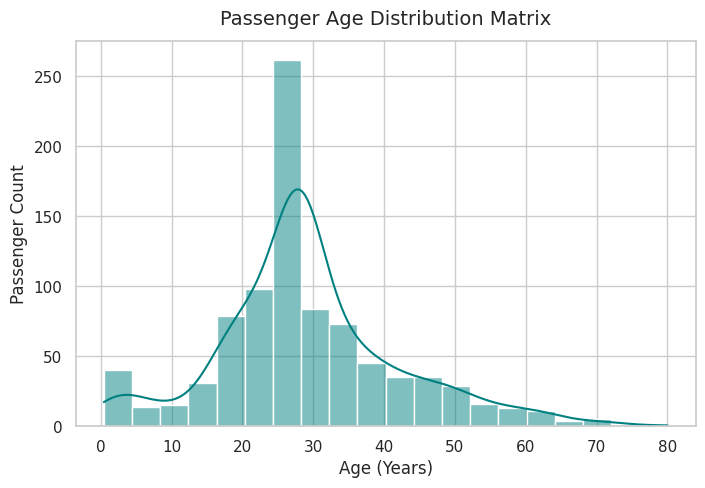

In [4]:
sns.histplot(df["Age"], bins=20, kde=True, color="teal")
plt.title("Passenger Age Distribution Matrix", fontsize=14, pad=12)
plt.xlabel("Age (Years)")
plt.ylabel("Passenger Count")
plt.show()

> **Takeaway:** The passenger population is heavily clustered between the ages of 20 and 40, indicating a large presence of young adults on board. The kernel density curve reveals a secondary minor spike under 10 years old, tracking families traveling together.

### Chart 2: Bar Chart - Survival Rate by Sex

/tmp/ipykernel_2550/1723235442.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=df, palette="muted", errorbar=None)


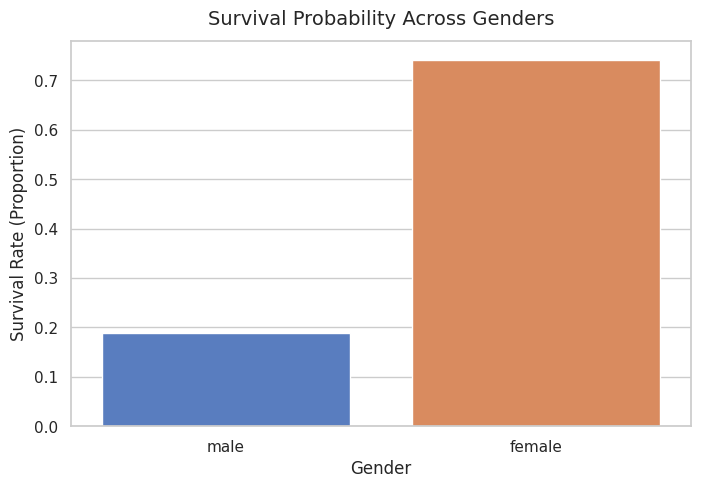

In [5]:
sns.barplot(x="Sex", y="Survived", data=df, palette="muted", errorbar=None)
plt.title("Survival Probability Across Genders", fontsize=14, pad=12)
plt.xlabel("Gender")
plt.ylabel("Survival Rate (Proportion)")
plt.show()

> **Takeaway:** There is a stark contrast in survival rates between genders, with female passengers achieving an approximate 74% survival probability compared to less than 20% for males. This reflects the strong adherence to maritime evacuation protocols prioritizing women and children.

### Chart 3: Boxplot - Fare Distribution by Passenger Class

/tmp/ipykernel_2550/844567548.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Fare", data=df, palette="deep")


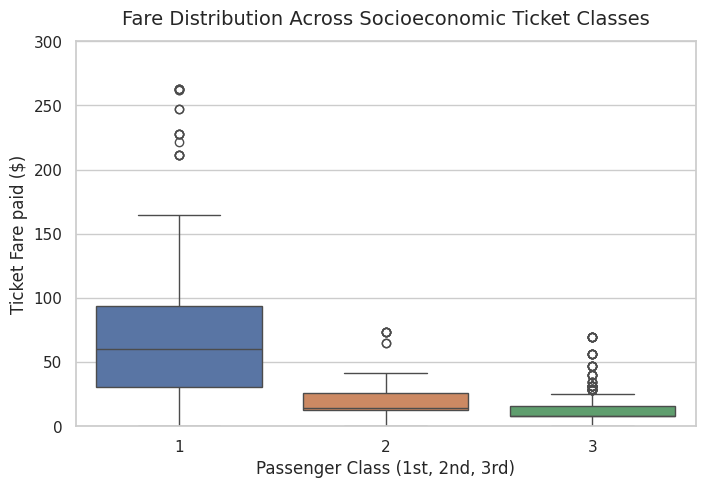

In [6]:
sns.boxplot(x="Pclass", y="Fare", data=df, palette="deep")
plt.title("Fare Distribution Across Socioeconomic Ticket Classes", fontsize=14, pad=12)
plt.xlabel("Passenger Class (1st, 2nd, 3rd)")
plt.ylabel("Ticket Fare paid ($)")
plt.ylim(0, 300) # Trim extreme outliers for visual clarity
plt.show()

> **Takeaway:** First-class fares show immense variance and multiple high-value outliers, stretching far beyond the tightly grouped economic costs of second and third class. This confirms distinct financial segmentation between passenger categories.

### Chart 4: Scatterplot - Age vs. Fare Colored by Survival Status

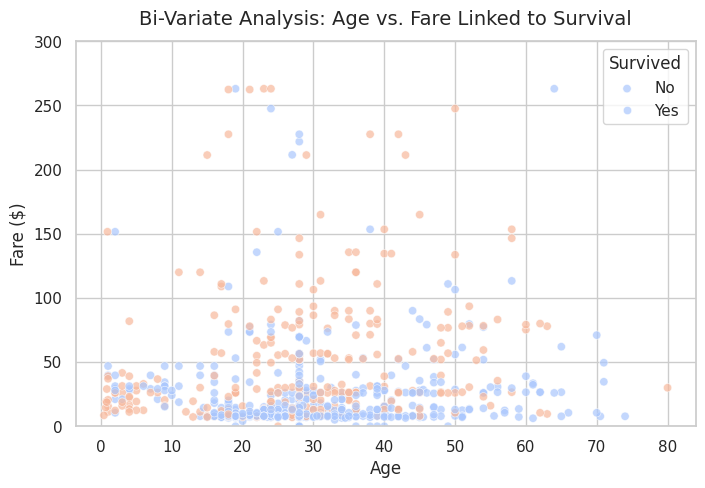

In [7]:
sns.scatterplot(x="Age", y="Fare", hue="Survived", alpha=0.7, palette="coolwarm", data=df)
plt.title("Bi-Variate Analysis: Age vs. Fare Linked to Survival", fontsize=14, pad=12)
plt.xlabel("Age")
plt.ylabel("Fare ($)")
plt.ylim(0, 300)
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

> **Takeaway:** The plot demonstrates that higher paying passengers (concentrated near the top of the grid) exhibit a higher density of survival indicators across almost all age brackets, showing that purchasing power significantly influenced safety access.

### Chart 5: Correlation Heatmap (Numeric Columns Only)

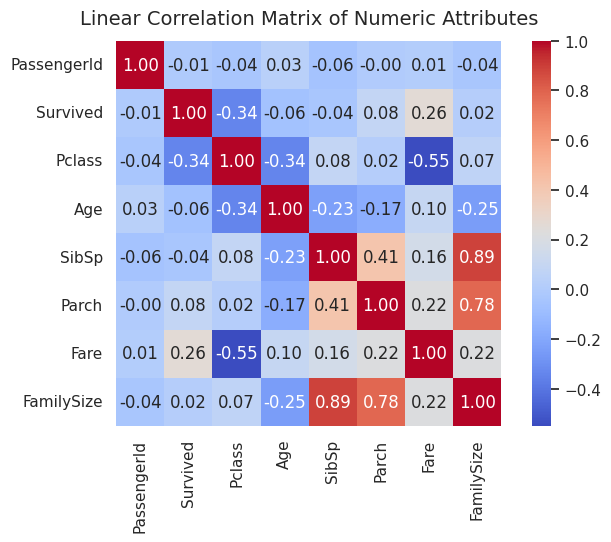

In [8]:
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Linear Correlation Matrix of Numeric Attributes", fontsize=14, pad=12)
plt.show()

> **Takeaway:** The matrix identifies a notable negative correlation between Passenger Class and Fare, mathematically verifying that lower class numbers correspond to much more expensive ticket brackets. Correlation links between survival and family metrics remain present but moderate.

## 4. Insights & Conclusion
* **Socioeconomic Advantage:** Both the boxplot and scatterplot confirm that booking class and high ticket fares directly improved a passenger's likelihood of survival.
* **Demographic Factors:** Age demographics combined with gender rules showcase that young adult males faced the highest mortality rates, whereas children and females were heavily preserved.
* **Dashboard Summary:** The consolidated visualizations highlight that survival was not random but stratified by gender, age, and class.